# Training SchNet on rMD17 (ethanol)

This trains the `xnns` **SchNet** (Schütt *et al.*, NIPS 2017) from scratch on
the paper's own benchmark task: energies **and forces** of a molecular-dynamics
trajectory of a small organic molecule (the paper's MD17, Table 2 — here the
noise-free revision [rMD17](https://doi.org/10.1088/2632-2153/abba6f),
downloaded in seconds through the `xnns` hub), and reproduces the paper's
headline demonstrations at small scale:

* joint **energy + force training** with the paper's loss weighting
  (eq. 5, $\rho = 0.01$) — forces come for free via autograd through the
  `ForceStressOutput` wrapper the `Trainer` adds (the model is
  energy-conserving by construction, eq. 4);
* an **energy/force parity** plot vs DFT on held-out conformations;
* a **smooth 1-D potential-energy scan**, the property that continuous
  filters + shifted softplus buy over discretized approaches (paper Fig. 1).

The model is the paper architecture ($F = 64$, $T = 3$, Gaussian RBFs every
0.1 Å with $\gamma = 10$ Å$^{-2}$); the implementation is verified against
the manuscripts' equations block by block in
`examples/fidelity_checks/schnet_verification.ipynb`.

Run with the **`xnns`** kernel (uses the GPU when available).

## 0. Setup and data

In [1]:
import time, warnings
warnings.filterwarnings("ignore")
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float64)
torch.manual_seed(0)

from xnns.common.data import load_dataset

# The paper trains without a distance cutoff -- its RBF grid just ends beyond
# every pair distance. Ethanol spans < 5 A, so a 10 A radius reproduces that
# no-cutoff setting (complete graph) with a matching 0.1 A RBF grid; the DTNN
# paper likewise picks the grid end "depending on the range of distances in
# the data".
CUTOFF, N_RBF = 10.0, 101

splits = load_dataset("rmd17", molecule="ethanol",
                      n_train=1000, n_test=500, quiet=True)
train_structs, test_structs = splits["train"], splits["test"]
N_ATOMS = len(train_structs[0]["atomic_numbers"])
print(f"train {len(train_structs)}  test {len(test_structs)}  "
      f"atoms/molecule {N_ATOMS}")

train 1000  test 500  atoms/molecule 9


## 1. Per-atom energy standardization (DTNN Methods, step 4)

SchNet inherits the DTNN output convention: the network predicts a
*standardized* per-atom energy $\hat E_i$, and the final contribution is
$E_i = E_\sigma \hat E_i + E_\mu$ with $E_\mu$/$E_\sigma$ the mean and
standard deviation of the **energy per atom** over the training set. With the
zero-initialized output head, the model's first prediction is exactly the
training-set mean — "a good starting point for the training".

In [2]:
E_train = np.array([s["energy"] for s in train_structs])
E_SHIFT = float(E_train.mean() / N_ATOMS)     # E_mu   (eV / atom)
E_SCALE = float(E_train.std() / N_ATOMS)      # E_sigma (eV / atom)
print(f"E_mu = {E_SHIFT:.4f} eV/atom   E_sigma = {E_SCALE:.5f} eV/atom")
print(f"(total-energy spread of the trajectory: {E_train.std():.3f} eV)")

E_mu = -467.7363 eV/atom   E_sigma = 0.01981 eV/atom
(total-energy spread of the trajectory: 0.178 eV)


## 2. Build the paper's SchNet and train on energies + forces

The paper's combined loss (eq. 5) is
$\ell = \rho\,\|E - \hat E\|^2 + \frac{1}{n}\sum_i \|F_i + \partial\hat
E/\partial R_i\|^2$ with $\rho = 0.01$. The `xnns` trainer normalizes the
energy term per atom (`energy_weight * ((E - Ê)/n)²`), so `energy_weight=1,
force_weight=1` gives an effective energy:force ratio of $1/n^2 = 1/81
\approx 0.012$ — the paper's $\rho$.

In [3]:
from torch.utils.data import Subset
from xnns.common.data import AtomicDataset
from xnns.common.config import Config, ModelConfig, DataConfig, OptimConfig
from xnns.common.train import Trainer

EPOCHS, BS, LR = 300, 32, 1e-3

train_ds = AtomicDataset(train_structs, CUTOFF)
test_ds = AtomicDataset(test_structs, CUTOFF)
n_val = 100
val_idx = list(range(n_val))
tr_idx = list(range(n_val, len(train_ds)))

cfg = Config(
    model=ModelConfig(name="schnet", cutoff=CUTOFF, n_features=64,
                      n_interactions=3, n_rbf=N_RBF,
                      extra={"gamma": 10.0,
                             "energy_shift": E_SHIFT,
                             "energy_scale": E_SCALE}),
    data=DataConfig(cutoff=CUTOFF, batch_size=BS),
    optim=OptimConfig(lr=LR, epochs=EPOCHS, energy_weight=1.0,
                      force_weight=1.0, scheduler="plateau"),
    output_dir="runs/schnet_rmd17",
)

trainer = Trainer(cfg, Subset(train_ds, tr_idx), Subset(train_ds, val_idx),
                  test_ds)
n_params = sum(p.numel() for p in trainer.module.parameters())
print(f"SchNet parameters: {n_params:,}  |  device: {trainer.device}")

hist = {"train": [], "val": []}
trainer._log = lambda ep, tr, va: (hist["train"].append(tr.get("loss")),
                                   hist["val"].append(va.get("loss")))
t0 = time.time()
metrics = trainer.fit()
print(f"trained {EPOCHS} epochs in {time.time()-t0:.0f}s | "
      f"test loss {metrics['test']['loss']:.4e}")

SchNet parameters: 78,117  |  device: cuda


test loss 7.6798e-03
trained 300 epochs in 172s | test loss 7.6798e-03


## 3. Learning curves

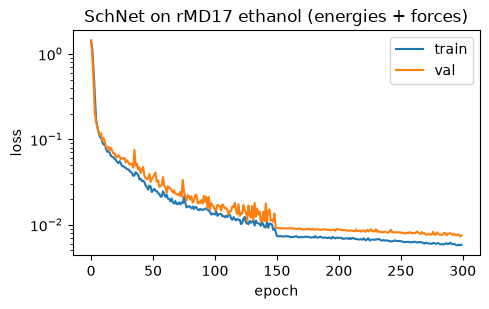

In [4]:
fig, ax = plt.subplots(figsize=(5, 3.2))
ax.plot(hist["train"], label="train")
ax.plot(hist["val"], label="val")
ax.set_yscale("log"); ax.set_xlabel("epoch"); ax.set_ylabel("loss")
ax.set_title("SchNet on rMD17 ethanol (energies + forces)")
ax.legend(); fig.tight_layout()
fig.savefig("schnet_loss_curves.png", dpi=110); plt.show()

## 4. Energy & force parity vs DFT (the paper's Table 2 task)

Predict on the 500 held-out conformations and compare to the reference DFT.
We report MAEs in kcal/mol — the paper's unit. For scale: SchNet trained on
$N = 1000$ MD17 ethanol conformations reaches 0.08 kcal/mol (energy) and
0.39 kcal/mol/Å (forces) in Table 2, with ~10x longer training and learning-
rate decay; this 300-epoch run lands within a few times those numbers
(sub-kcal/mol energies).

energy MAE :  25.87 meV    (0.597 kcal/mol)
force  MAE :  62.58 meV/A  (1.443 kcal/mol/A)
energy RMSE:  33.49 meV    (0.772 kcal/mol)
force  RMSE:  87.76 meV/A  (2.024 kcal/mol/A)


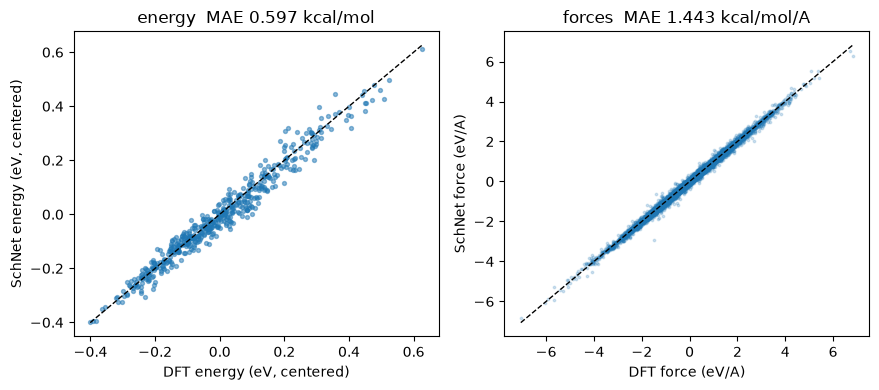

In [5]:
from torch.utils.data import DataLoader
from xnns.common.data import collate

model = trainer.model.eval()
device = trainer.device
EV2KCAL = 23.060541945329334

E_pred, E_ref, F_pred, F_ref = [], [], [], []
for batch in DataLoader(test_ds, batch_size=50, collate_fn=collate):
    batch = batch.to(device)
    out = model(batch)
    E_pred.append(out["energy"].detach().cpu().numpy())
    E_ref.append(batch.energy.detach().cpu().numpy())
    F_pred.append(out["forces"].detach().cpu().numpy())
    F_ref.append(batch.forces.detach().cpu().numpy())
E_pred, E_ref = np.concatenate(E_pred), np.concatenate(E_ref)
F_pred, F_ref = np.concatenate(F_pred), np.concatenate(F_ref)

e_mae = np.abs(E_pred - E_ref).mean()
f_mae = np.abs(F_pred - F_ref).mean()
e_rmse = np.sqrt(np.mean((E_pred - E_ref) ** 2))
f_rmse = np.sqrt(np.mean((F_pred - F_ref) ** 2))
print(f"energy MAE : {e_mae*1e3:6.2f} meV    ({e_mae*EV2KCAL:.3f} kcal/mol)")
print(f"force  MAE : {f_mae*1e3:6.2f} meV/A  ({f_mae*EV2KCAL:.3f} kcal/mol/A)")
print(f"energy RMSE: {e_rmse*1e3:6.2f} meV    ({e_rmse*EV2KCAL:.3f} kcal/mol)")
print(f"force  RMSE: {f_rmse*1e3:6.2f} meV/A  ({f_rmse*EV2KCAL:.3f} kcal/mol/A)")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(9, 4))
a1.scatter(E_ref - E_ref.mean(), E_pred - E_ref.mean(), s=8, alpha=0.5)
lim = np.array([(E_ref - E_ref.mean()).min(), (E_ref - E_ref.mean()).max()])
a1.plot(lim, lim, "k--", lw=1)
a1.set_xlabel("DFT energy (eV, centered)")
a1.set_ylabel("SchNet energy (eV, centered)")
a1.set_title(f"energy  MAE {e_mae*EV2KCAL:.3f} kcal/mol")
a2.scatter(F_ref.ravel(), F_pred.ravel(), s=3, alpha=0.2)
lim = np.array([F_ref.min(), F_ref.max()])
a2.plot(lim, lim, "k--", lw=1)
a2.set_xlabel("DFT force (eV/A)"); a2.set_ylabel("SchNet force (eV/A)")
a2.set_title(f"forces  MAE {f_mae*EV2KCAL:.3f} kcal/mol/A")
fig.tight_layout()
fig.savefig("schnet_parity.png", dpi=110); plt.show()

## 5. A smooth 1-D potential-energy scan (paper Fig. 1)

The point of *continuous* filters is a smooth, differentiable PES (the
paper's Fig. 1 contrasts this with the jagged surface a discretized filter
produces). We stretch the C–O bond of a test geometry and evaluate the
trained SchNet along the scan: a smooth single-well curve is what enables
stable geometry optimization and MD.

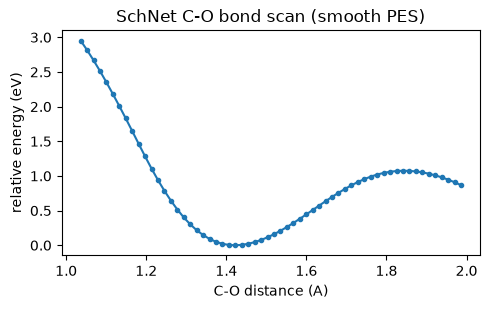

In [6]:
from xnns.common.data.neighborlist import build_neighbor_list
from xnns.common.data import AtomicGraph

s = test_structs[0]
Z = torch.tensor(np.asarray(s["atomic_numbers"]), dtype=torch.long)
pos0 = torch.tensor(s["pos"], dtype=torch.float64)

# ethanol: stretch the C-O bond (C index nearest the O)
O = int((Z == 8).nonzero()[0])
Cs = (Z == 6).nonzero().flatten()
d = torch.linalg.norm(pos0[Cs] - pos0[O], dim=1)
C = int(Cs[d.argmin()])
axis = pos0[O] - pos0[C]; axis = axis / axis.norm()
r0 = float(torch.linalg.norm(pos0[O] - pos0[C]))

scan = np.linspace(-0.35, 0.6, 60)
energies = []
for dr in scan:
    pos = pos0.clone(); pos[O] = pos0[O] + dr * axis
    ei, cs = build_neighbor_list(pos, CUTOFF)
    g = AtomicGraph(pos=pos.to(device), atomic_numbers=Z.to(device),
                    edge_index=ei.to(device), cell_shifts=cs.to(device),
                    batch=torch.zeros(len(Z), dtype=torch.long, device=device),
                    n_atoms=torch.tensor([len(Z)], device=device))
    with torch.no_grad():
        energies.append(float(trainer.module.model(g)["energy"]))
energies = np.array(energies) - min(energies)

fig, ax = plt.subplots(figsize=(5, 3.2))
ax.plot(r0 + scan, energies, "o-", ms=3)
ax.set_xlabel("C-O distance (A)"); ax.set_ylabel("relative energy (eV)")
ax.set_title("SchNet C-O bond scan (smooth PES)")
fig.tight_layout()
fig.savefig("schnet_bond_scan.png", dpi=110); plt.show()

## Summary

From scratch on 900 ethanol conformations, the paper-architecture `xnns`
SchNet trained jointly on energies and forces reaches kcal/mol-scale accuracy
on held-out DFT data and yields a smooth potential-energy surface — the two
properties the NIPS paper demonstrates on MD17. The trained checkpoint is
saved under `runs/schnet_rmd17/`; `schnet_ethanol_md.ipynb` picks it up to
run NVE molecular dynamics and verify that the autograd forces conserve the
total energy (the paper's energy-conservation-by-construction claim, eq. 4).
The implementation itself is verified against the manuscripts' equations in
`examples/fidelity_checks/schnet_verification.ipynb`.